# **Credit Risk-Based Loan Pricing Engine**

## Project Overview

This project builds a professional credit risk pricing model for consumer loans, using the **Basel-aligned Expected Loss framework** — the industry-standard methodology used by banks and fintech lenders worldwide to price lending risk.

### Business Problem
Lenders must price loans accurately: charging a high enough interest rate to cover expected losses from default, while remaining competitive enough to attract creditworthy borrowers. This project answers a core credit risk question:

> **"Given a borrower's financial profile (income, debt ratio, credit history...), what interest rate should they be charged?"**

### Objectives
1. Model the **Probability of Default (PD)** — the likelihood a borrower fails to repay within two years — using Logistic Regression.
2. Benchmark the PD model against a modern **Machine Learning approach** (XGBoost), evaluating the trade-off between interpretability and predictive accuracy — critical in regulated credit decisions.
3. Estimate **Loss Given Default (LGD)** — the proportion of exposure lost if default occurs — using documented industry-standard assumptions for unsecured consumer loans.
4. Estimate **Exposure at Default (EAD)** — the amount at risk at the point of default.
5. Combine all three into **Expected Loss** (`PD × LGD × EAD`), the core Basel II/III risk equation used by financial institutions globally.
6. Convert Expected Loss into a **risk-based interest rate**, adding cost of capital and profit margin.
7. Deliver the pricing logic through an **interactive dashboard**.

### Dataset
This project uses the **Give Me Some Credit** dataset — a well-known Kaggle credit scoring dataset containing 150,000 borrower records with financial and credit history features, widely used in credit risk modeling research and education.

- **Target variable**: `SeriousDlqin2yrs` — binary indicator of serious delinquency (90+ days past due) within two years.
- **Features**: credit utilization, age, payment history (30-59/60-89/90+ days late), debt ratio, monthly income, number of open credit lines, real estate loans, and number of dependents.

### Why This Methodology
The PD × LGD × EAD framework is the regulatory standard under Basel II/III for credit risk capital requirements. It separates the pricing problem into three independently estimable components, producing a transparent, auditable risk assessment — a requirement expected by financial regulators and credit risk committees.

# **1. Data Loading & Exploration (EDA)**

## 1.1 Load Dataset

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Ensure figures directory exists
os.makedirs('/workspaces/credit-risk-loan-pricing/reports/figures', exist_ok=True)

# Load dataset
df = pd.read_csv('/workspaces/credit-risk-loan-pricing/data/raw/cs-training.csv')

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (150000, 12)


## 1.2 Initial Data Inspection

In [17]:
# First look at the data
print(df.head())
print("\n--- Columns ---")
print(df.columns.tolist())
print("\n--- Info ---")
df.info()
print("\n--- Missing Values ---")
print(df.isnull().sum())

   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0           1                 1                              0.766127   45   
1           2                 0                              0.957151   40   
2           3                 0                              0.658180   38   
3           4                 0                              0.233810   30   
4           5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13                   

## 1.3 Univariate Analysis (Distributions of Key Variables)

In [18]:
# Remove unnamed index column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("Dropped 'Unnamed: 0' column.")

print(f"Final shape: {df.shape}")
print(df.columns.tolist())

Dropped 'Unnamed: 0' column.
Final shape: (150000, 11)
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


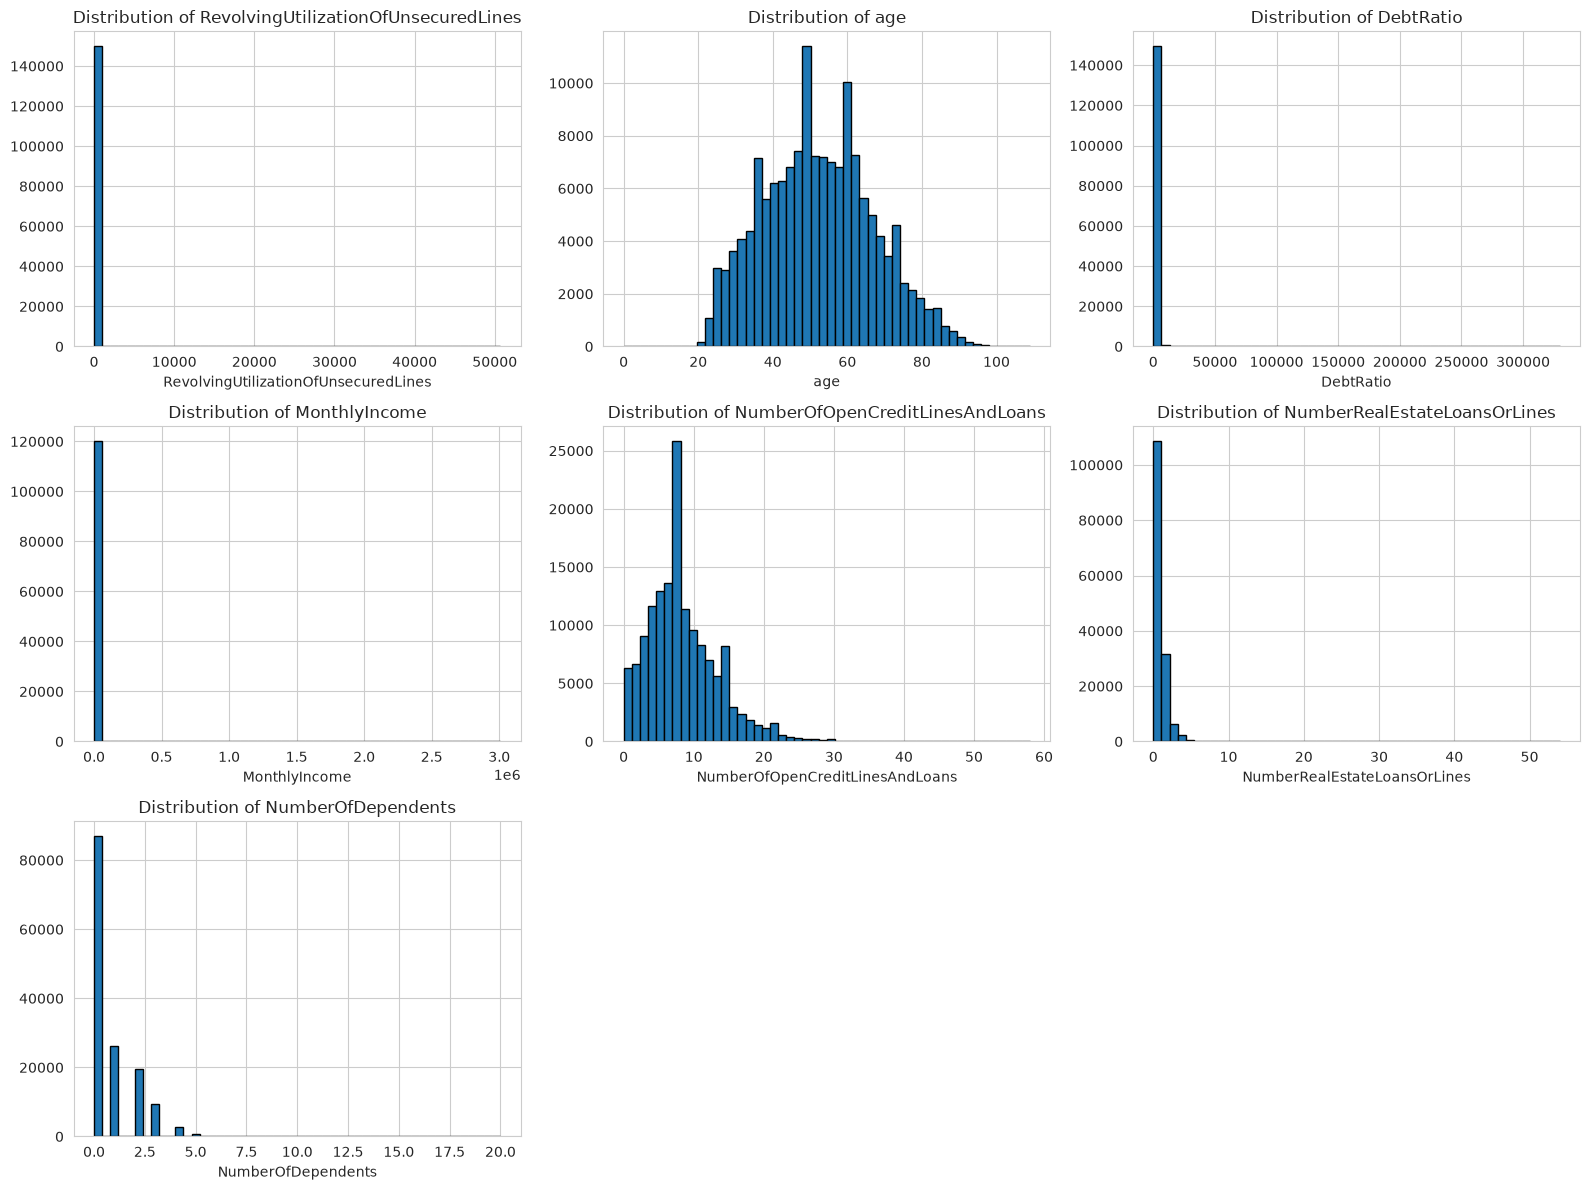

In [19]:
numerical_cols = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
                   'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
                   'NumberRealEstateLoansOrLines', 'NumberOfDependents']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=50, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

for j in range(len(numerical_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('/workspaces/credit-risk-loan-pricing/reports/figures/univariate_numerical.png', dpi=150)
plt.show()

In [20]:
print("=== Summary Statistics ===")
print(df[numerical_cols].describe())

=== Summary Statistics ===
       RevolvingUtilizationOfUnsecuredLines            age      DebtRatio  \
count                         150000.000000  150000.000000  150000.000000   
mean                               6.048438      52.295207     353.005076   
std                              249.755371      14.771866    2037.818523   
min                                0.000000       0.000000       0.000000   
25%                                0.029867      41.000000       0.175074   
50%                                0.154181      52.000000       0.366508   
75%                                0.559046      63.000000       0.868254   
max                            50708.000000     109.000000  329664.000000   

       MonthlyIncome  NumberOfOpenCreditLinesAndLoans  \
count   1.202690e+05                    150000.000000   
mean    6.670221e+03                         8.452760   
std     1.438467e+04                         5.145951   
min     0.000000e+00                         0.0000

## 1.4 Target Variable Analysis (Default Rate)

=== Target Variable Distribution ===
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Default rate: 6.68%


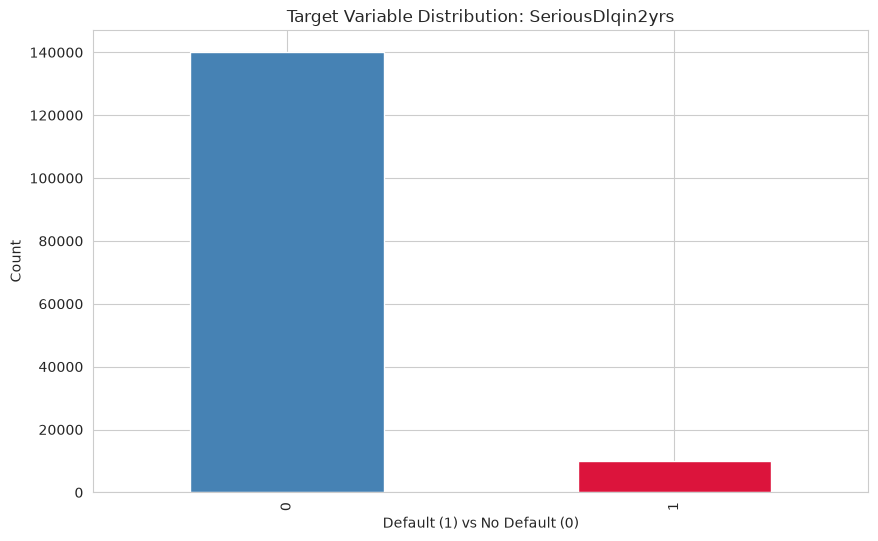

In [21]:
print("=== Target Variable Distribution ===")
print(df['SeriousDlqin2yrs'].value_counts())
print(f"\nDefault rate: {df['SeriousDlqin2yrs'].mean()*100:.2f}%")

df['SeriousDlqin2yrs'].value_counts().plot(kind='bar', color=['steelblue', 'crimson'])
plt.title('Target Variable Distribution: SeriousDlqin2yrs')
plt.xlabel('Default (1) vs No Default (0)')
plt.ylabel('Count')
plt.savefig('/workspaces/credit-risk-loan-pricing/reports/figures/target_distribution.png', dpi=150)
plt.show()

---

# 2. Data Cleaning & Feature Engineering

## 2.1 Handle Missing Values

In [22]:
# MonthlyIncome: impute with median (robust to outliers, standard practice)
median_income = df['MonthlyIncome'].median()
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(median_income)

# NumberOfDependents: impute with mode (most common value, typically 0)
mode_dependents = df['NumberOfDependents'].mode()[0]
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(mode_dependents)

print(f"Median income used for imputation: {median_income}")
print(f"Mode dependents used for imputation: {mode_dependents}")
print(f"\nRemaining missing values:\n{df.isnull().sum().sum()} total")

Median income used for imputation: 5400.0
Mode dependents used for imputation: 0.0

Remaining missing values:
0 total


## 2.2 Handle Outliers

In [23]:
# Age: remove impossible values (age=0 cannot have credit history)
print(f"Records with age == 0: {(df['age'] == 0).sum()}")
df = df[df['age'] > 0].copy()
print(f"Shape after removing age=0: {df.shape}")

Records with age == 0: 1
Shape after removing age=0: (149999, 11)


In [24]:
# RevolvingUtilization should realistically be capped (it's a ratio)
print(df['RevolvingUtilizationOfUnsecuredLines'].quantile([0.95, 0.99, 0.999, 1.0]))

# Cap at 2 (utilization above 200% is extreme/erroneous)
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)

0.950        1.000000
0.990        1.092958
0.999     1571.012000
1.000    50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64


In [25]:
# DebtRatio: same issue, extreme outliers
print(df['DebtRatio'].quantile([0.95, 0.99, 0.999, 1.0]))

# Cap at 5 (a debt ratio above 500% is not economically meaningful for pricing)
df['DebtRatio'] = df['DebtRatio'].clip(upper=5)

0.950      2449.000
0.990      4979.080
0.999     10613.148
1.000    329664.000
Name: DebtRatio, dtype: float64


## 2.3 Feature Engineering

In [26]:
# Combine all "late payment" indicators into a single total count
df['TotalTimesPastDue'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] +
    df['NumberOfTime60-89DaysPastDueNotWorse'] +
    df['NumberOfTimes90DaysLate']
)

print(df['TotalTimesPastDue'].describe())
print(f"\nRecords with 0 past due incidents: {(df['TotalTimesPastDue'] == 0).sum()} ({(df['TotalTimesPastDue'] == 0).mean()*100:.1f}%)")

count    149999.000000
mean          0.927393
std          12.466246
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         294.000000
Name: TotalTimesPastDue, dtype: float64

Records with 0 past due incidents: 119637 (79.8%)


In [27]:
bins_age = [18, 30, 40, 50, 60, 70, 110]
labels_age = ['18-30', '31-40', '41-50', '51-60', '61-70', '70+']
df['Age_band'] = pd.cut(df['age'], bins=bins_age, labels=labels_age, include_lowest=True)

print(df['Age_band'].value_counts().sort_index())

Age_band
18-30    10757
31-40    24339
41-50    35037
51-60    34806
61-70    27424
70+      17636
Name: count, dtype: int64


Default rate by total past-due incidents:
TotalTimesPastDue
(-1, 0]     0.027283
(0, 1]      0.122144
(1, 2]      0.240828
(2, 5]      0.399705
(5, 100]    0.612081
Name: SeriousDlqin2yrs, dtype: float64


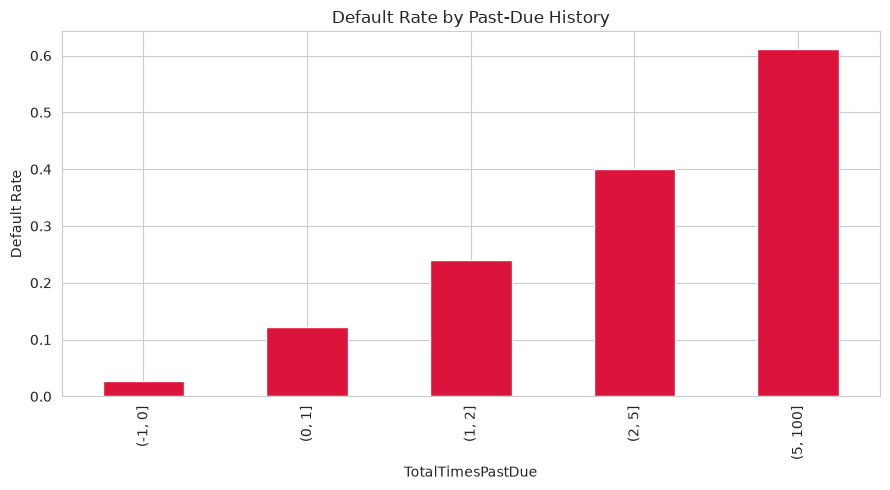

In [28]:
# Validation: default rate by past-due history
default_by_pastdue = df.groupby(pd.cut(df['TotalTimesPastDue'], bins=[-1, 0, 1, 2, 5, 100]))['SeriousDlqin2yrs'].mean()
print("Default rate by total past-due incidents:")
print(default_by_pastdue)

default_by_pastdue.plot(kind='bar', figsize=(9,5), title='Default Rate by Past-Due History', color='crimson')
plt.ylabel('Default Rate')
plt.tight_layout()
plt.savefig('/workspaces/credit-risk-loan-pricing/reports/figures/default_by_pastdue.png', dpi=150)
plt.show()

In [29]:
df.to_csv('/workspaces/credit-risk-loan-pricing/data/processed/clean_credit_data.csv', index=False)
print(f"✅ Processed data saved: {df.shape}")

✅ Processed data saved: (149999, 13)
